# Explore latent space

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap

from sdss.metadata import MetaData

meta = MetaData()

# Custom Functions

## Scale data

In [3]:
def standard_scaler(latent_arr):

    scaler = StandardScaler()
    
    latent_scaled = scaler.fit_transform(latent_arr)
    
    return latent_scaled

## corner plot

In [4]:
def make_corner(data_subset, title):
    grid = sns.PairGrid(data_subset, corner=True, diag_sharey=False)
    grid.map_lower(sns.scatterplot, s=1, alpha=0.1, color='teal')
    grid.map_diag(sns.kdeplot, fill=True, color='teal')
    grid.fig.suptitle(title, y=1.02)
    return grid

# Config

## Directories

In [6]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
ch4_dir = f"{thesis_dir}/chapters/04_figures"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
bins_ids = [f'bin_{i:02d}' for i in range(4)] 

## Data

In [7]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)


## Latent per bin

In [8]:
latent_bin_dict = {}

for bin_id in bins_ids:

    latent_bin_dict[bin_id] = np.load(
        f"{latent_dir}/{bin_id}/latent_{bin_id}.npy"
    )

# Corner plot

In [9]:
# bin_id = 'bin_03'

# latent_arr = latent_bin_dict[bin_id].copy()
# df_latent = pd.DataFrame(latent_arr, columns=[f'w_{i+1}' for i in range(12)])

# latent_scaled = standard_scaler(latent_arr)
# df_latent_scaled = pd.DataFrame(latent_scaled, columns=[f'w_{i+1}' for i in range(12)])


In [10]:
# def plot_dual_block(
#     data, group_a_idx, group_b_idx,
#     gridsize=100
# ):
#     # Both groups are size 6
#     n = 6 
#     fig, axes = plt.subplots(n, n, figsize=(14, 12))
    
#     for i in range(n):
#         for j in range(n):

#             ax = axes[i, j]
            
#             if i > j:
#                 # LOWER TRIANGLE: Group A (w1-w6)
#                 # i and j are local [0-5], map to group_a_idx
#                 v1 = group_a_idx[j]
#                 v2 = group_a_idx[i]
#                 ax.hexbin(
#                     data[:, v1], data[:, v2],
#                     gridsize=gridsize, cmap='viridis',
#                     mincnt=1
#                 )
                
#                 # Labels for Group A
#                 if i == n - 1: ax.set_xlabel(f"w_{v1+1}", fontweight='bold')
#                 if j == 0: ax.set_ylabel(f"w_{v2+1}", fontweight='bold')
                
#             elif i < j:
#                 # UPPER TRIANGLE: Group B (w7-w12)
#                 # Map local indices to group_b_idx
#                 v1, v2 = group_b_idx[j], group_b_idx[i]
#                 ax.hexbin(
#                     data[:, v1], data[:, v2],
#                     gridsize=gridsize,
#                     cmap='viridis',
#                     mincnt=1
#                 )
                
#                 # Labels for Group B (Top and Right)
#                 if i == 0: 
#                     ax.xaxis.set_label_position('top')
#                     ax.set_xlabel(f"w_{v1+1}", fontweight='bold')
#                 if j == n - 1: 
#                     ax.yaxis.set_label_position('right')
#                     ax.set_ylabel(f"w_{v2+1}", fontweight='bold')
                
#             else:
#                 # DIAGONAL: Variable Identifier
#                 # ax.text(0.5, 0.5, f"w_{group_a_idx[i]+1}\nvs\nw_{group_b_idx[i]+1}", 
#                         # ha='center', va='center', fontsize=10, fontweight='bold')
#                 ax.set_xticks([]); ax.set_yticks([])
            

#     return fig, axes

# # Execute
# idx_A = list(range(6))
# idx_B = list(range(6, 12))
# fig_dual = plot_dual_block(latent_scaled, idx_A, idx_B)
# plt.show()

In [11]:
# def plot_cross_group(data, group_a_idx, group_b_idx, gridsize=100):
#     # Both groups have 6 variables
#     n_a = len(group_a_idx)
#     n_b = len(group_b_idx)
    
#     fig, axes = plt.subplots(n_b, n_a, figsize=(15, 14))
    
#     for i, b_idx in enumerate(group_b_idx):
#         for j, a_idx in enumerate(group_a_idx):
#             ax = axes[i, j]
            
#             # Use hexbin to maintain consistency with your previous plots
#             hb = ax.hexbin(data[:, a_idx], data[:, b_idx], 
#                            gridsize=35, cmap='viridis', mincnt=1)
            
#             # # Set axis limits to maintain the same "zoom" level
#             # ax.set_xlim(-10, 5)
#             # ax.set_ylim(-5, 5)
            
#             # Labeling the outer axes only to prevent clutter
#             if i == n_b - 1:
#                 ax.set_xlabel(f"w_{a_idx+1}", fontweight='bold')
#             if j == 0:
#                 ax.set_ylabel(f"w_{b_idx+1}", fontweight='bold')
            
#             # Optional: cleaner ticks for internal plots
#             if i < n_b - 1: ax.set_xticklabels([])
#             if j > 0: ax.set_yticklabels([])


#     return fig, axes

# # Define your groups
# idx_A = list(range(6))
# idx_B = list(range(6, 12))

# # Generate the plot
# fig_cross = plot_cross_group(latent_scaled, idx_A, idx_B)
# plt.show()

In [12]:
# # Create a Pairplot for of latent dimensions
# # This helps check if the KLD/MMD worked: they should look roughly Gaussian
# sns.pairplot(df_latent_scaled, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 10})
# plt.suptitle("Pairwise Projections of Latent Dimensions", y=1.02)
# plt.show()

# Umap

## bin_03

In [14]:
bin_id = 'bin_03'
latent_arr = latent_bin_dict[bin_id].copy()
latent_scaled = standard_scaler(latent_arr)

umap_params = {
    'n_components':2,
    'n_neighbors':60, 'metric':'manhattan',
    'random_state':42,
    'low_memory':False,
    'min_dist': None
}

embeddings_dict = {} 
min_dist_list = [0.01, 0.05, 0.1, 0.5]

for min_dist in min_dist_list: 

    print(f'min dist {min_dist}')
    umap_params['min_dist'] = min_dist

    reducer = umap.UMAP(**umap_params)
    _embedding = reducer.fit_transform(latent_scaled)

    embeddings_dict[f'{min_dist}'] = _embedding

min dist 0.01


/home/elom/.venv/phd/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min dist 0.05


/home/elom/.venv/phd/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min dist 0.1


/home/elom/.venv/phd/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min dist 0.5


/home/elom/.venv/phd/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [61]:
for min_dist, embedding in embeddings_dict.items():
    _min_dist = min_dist.replace('.', '_')
    save_to = f"{latent_dir}/{bin_id}/umap/umap_min_dist_{_min_dist}_{bin_id}.npy"
    np.save(save_to, embedding)

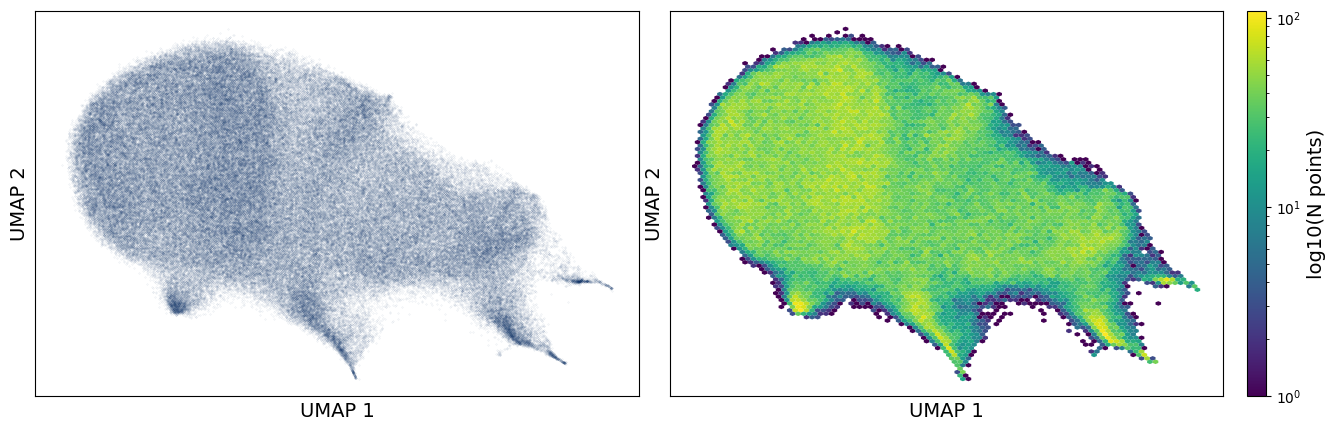

In [64]:
min_dist = '0.01'
embedding = embeddings_dict[min_dist]

x = embedding[:, 0]
y = embedding[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'wspace': 0.05})

# -------------------------------------------------------------
# Left Panel: Standard Scatter Plot
# -------------------------------------------------------------
# Use s=0.1 and alpha=0.1 to handle the extreme density of 180k points
axes[0].scatter(x, y, s=0.05, alpha=0.15, color='#08306B', edgecolors=None)
# axes[0].set_title(f'UMAP Scatter (min_dist = {min_dist})', fontsize=16)

# -------------------------------------------------------------
# Right Panel: 2D Hexbin Density Plot
# -------------------------------------------------------------
hb = axes[1].hexbin(
    x, y,
    gridsize=90,
    cmap='viridis', bins='log',
    mincnt=1, linewidths=0
)
# axes[1].set_title(f'UMAP Log-Density (min_dist = {min_dist})', fontsize=16)

cb = fig.colorbar(hb, ax=axes[1], fraction=0.046, pad=0.04)
cb.set_label('log10(N points)', fontsize=14)

# Clean up the axes (UMAP coordinates are relative, so ticks don't mean much)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('UMAP 1', fontsize=14)
    ax.set_ylabel('UMAP 2', fontsize=14)
